In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
BASE_DIR = Path("..").resolve()
PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIG_DIR = BASE_DIR / "figures" / "part1"

FIG_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
spot = pd.read_csv(PROCESSED_DIR / "audusd_spot_processed.csv", parse_dates=["Date"])
cpi = pd.read_csv(PROCESSED_DIR / "audusd_cpi_processed.csv", parse_dates=["Date"])
strategy_data = pd.read_csv(PROCESSED_DIR / "audusd_strategy_data.csv", parse_dates=["Date"])

print("spot:", spot.shape)
print("cpi:", cpi.shape)
print("strategy_data:", strategy_data.shape)

strategy_data.head()

spot: (181, 3)
cpi: (180, 6)
strategy_data: (179, 15)


,Date,spot,fx_return,rate_au,rate_us,cpi_au,cpi_us,infl_au,infl_us,infl_diff,rate_diff,signal,carry_component,fx_component,strategy_return
0,2009-02-28,0.642219,0.005827,3.35,0.16,64.206667,212.193,0.000363,0.004961,-0.004597,3.19,1,0.002658,0.005827,0.008485
1,2009-03-31,0.691802,0.074370,3.25,0.17,64.230000,212.709,0.000363,0.002429,-0.002065,3.08,1,0.002567,0.074370,0.076937
2,2009-04-30,0.726691,0.049202,3.06,0.04,64.336667,213.240,0.001659,0.002493,-0.000834,3.02,1,0.002517,0.049202,0.051719
3,2009-05-31,0.801025,0.097391,3.00,0.14,64.443333,213.856,0.001657,0.002885,-0.001228,2.86,1,0.002383,0.097391,0.099774
4,2009-06-30,0.806192,0.006429,3.00,0.17,64.550000,215.693,0.001654,0.008553,-0.006899,2.83,1,0.002358,0.006429,0.008787


In [5]:
df = strategy_data[
    [
        "Date",
        "spot",
        "fx_return",
        "rate_au",
        "rate_us",
        "infl_au",
        "infl_us",
    ]
].copy()

# Exchange rate convention:
# S_t = S(USD/AUD) = AUD/USD market quote = USD per 1 AUD
# An increase in S_t means AUD appreciation against USD.

df["actual_fx_change"] = df["fx_return"]

# UIP-implied change for S(USD/AUD):
# Δs = i_US - i_AUS
# Rates are annualized percentages, so divide by 100 and by 12.
df["uip_implied_change"] = (df["rate_us"] - df["rate_au"]) / 100 / 12

# PPP-implied change for S(USD/AUD):
# Δs = π_US - π_AUS
df["ppp_implied_change"] = df["infl_us"] - df["infl_au"]

part1 = df.dropna(
    subset=[
        "actual_fx_change",
        "uip_implied_change",
        "ppp_implied_change",
    ]
).copy()

part1.head(12)

,Date,spot,fx_return,rate_au,rate_us,infl_au,infl_us,actual_fx_change,uip_implied_change,ppp_implied_change
0,2009-02-28,0.642219,0.005827,3.35,0.16,0.000363,0.004961,0.005827,-0.002658,0.004597
1,2009-03-31,0.691802,0.074370,3.25,0.17,0.000363,0.002429,0.074370,-0.002567,0.002065
2,2009-04-30,0.726691,0.049202,3.06,0.04,0.001659,0.002493,0.049202,-0.002517,0.000834
3,2009-05-31,0.801025,0.097391,3.00,0.14,0.001657,0.002885,0.097391,-0.002383,0.001228
4,2009-06-30,0.806192,0.006429,3.00,0.17,0.001654,0.008553,0.006429,-0.002358,0.006899
5,2009-07-31,0.835631,0.035866,3.00,0.14,0.003145,-0.001587,0.035866,-0.002383,-0.004732
6,2009-08-31,0.842886,0.008644,3.00,0.11,0.003135,0.002240,0.008644,-0.002408,-0.000895
7,2009-09-30,0.883783,0.047379,3.00,0.06,0.003125,0.000625,0.047379,-0.002450,-0.002500
8,2009-10-31,0.900982,0.019274,3.21,0.01,0.001789,0.000963,0.019274,-0.002667,-0.000826
9,2009-11-30,0.917600,0.018276,3.48,0.08,0.001786,0.000708,0.018276,-0.002833,-0.001078


In [6]:
part1["uip_deviation"] = part1["uip_implied_change"] - part1["actual_fx_change"]
part1["ppp_deviation"] = part1["ppp_implied_change"] - part1["actual_fx_change"]

part1[
    [
        "Date",
        "actual_fx_change",
        "uip_implied_change",
        "ppp_implied_change",
        "uip_deviation",
        "ppp_deviation",
    ]
].head(12)

,Date,actual_fx_change,uip_implied_change,ppp_implied_change,uip_deviation,ppp_deviation
0,2009-02-28,0.005827,-0.002658,0.004597,-0.008485,-0.001230
1,2009-03-31,0.074370,-0.002567,0.002065,-0.076937,-0.072304
2,2009-04-30,0.049202,-0.002517,0.000834,-0.051719,-0.048368
3,2009-05-31,0.097391,-0.002383,0.001228,-0.099774,-0.096163
4,2009-06-30,0.006429,-0.002358,0.006899,-0.008787,0.000471
5,2009-07-31,0.035866,-0.002383,-0.004732,-0.038249,-0.040598
6,2009-08-31,0.008644,-0.002408,-0.000895,-0.011053,-0.009539
7,2009-09-30,0.047379,-0.002450,-0.002500,-0.049829,-0.049879
8,2009-10-31,0.019274,-0.002667,-0.000826,-0.021941,-0.020101
9,2009-11-30,0.018276,-0.002833,-0.001078,-0.021109,-0.019354


In [7]:
summary_part1 = pd.DataFrame({
    "metric": [
        "Mean actual FX change",
        "Mean UIP-implied change",
        "Mean PPP-implied change",
        "Std actual FX change",
        "Std UIP-implied change",
        "Std PPP-implied change",
        "Std UIP deviation",
        "Std PPP deviation",
    ],
    "value": [
        part1["actual_fx_change"].mean(),
        part1["uip_implied_change"].mean(),
        part1["ppp_implied_change"].mean(),
        part1["actual_fx_change"].std(),
        part1["uip_implied_change"].std(),
        part1["ppp_implied_change"].std(),
        part1["uip_deviation"].std(),
        part1["ppp_deviation"].std(),
    ]
})

summary_part1

,metric,value
0,Mean actual FX change,0.000373
1,Mean UIP-implied change,-0.001206
2,Mean PPP-implied change,-0.000076
3,Std actual FX change,0.033698
4,Std UIP-implied change,0.001596
5,Std PPP-implied change,0.003350
6,Std UIP deviation,0.033852
7,Std PPP deviation,0.033730


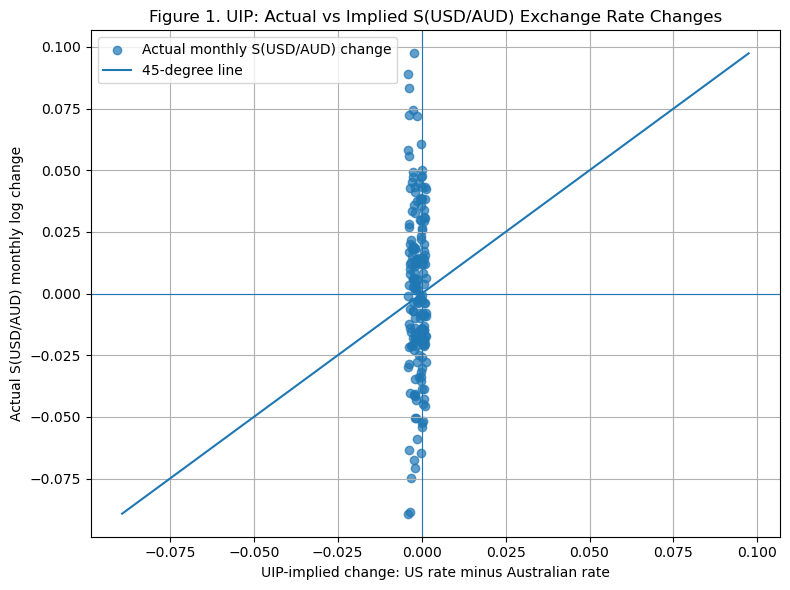

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(
    part1["uip_implied_change"],
    part1["actual_fx_change"],
    alpha=0.7,
    label="Actual monthly S(USD/AUD) change"
)

xmin = min(part1["uip_implied_change"].min(), part1["actual_fx_change"].min())
xmax = max(part1["uip_implied_change"].max(), part1["actual_fx_change"].max())

plt.plot([xmin, xmax], [xmin, xmax], label="45-degree line")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.title("Figure 1. UIP: Actual vs Implied S(USD/AUD) Exchange Rate Changes")
plt.xlabel("UIP-implied change: US rate minus Australian rate")
plt.ylabel("Actual S(USD/AUD) monthly log change")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(FIG_DIR / "figure1_uip_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

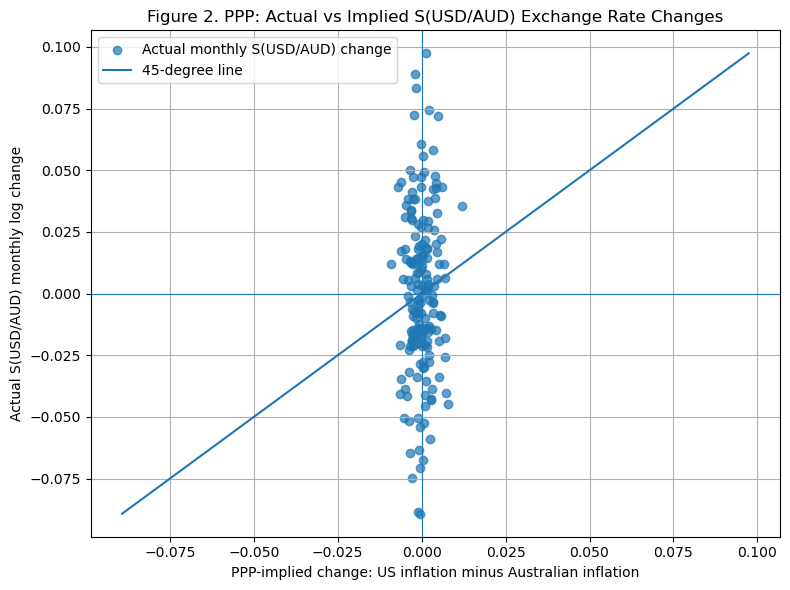

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    part1["ppp_implied_change"],
    part1["actual_fx_change"],
    alpha=0.7,
    label="Actual monthly S(USD/AUD) change"
)

xmin = min(part1["ppp_implied_change"].min(), part1["actual_fx_change"].min())
xmax = max(part1["ppp_implied_change"].max(), part1["actual_fx_change"].max())

plt.plot([xmin, xmax], [xmin, xmax], label="45-degree line")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.title("Figure 2. PPP: Actual vs Implied S(USD/AUD) Exchange Rate Changes")
plt.xlabel("PPP-implied change: US inflation minus Australian inflation")
plt.ylabel("Actual S(USD/AUD) monthly log change")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(FIG_DIR / "figure2_ppp_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

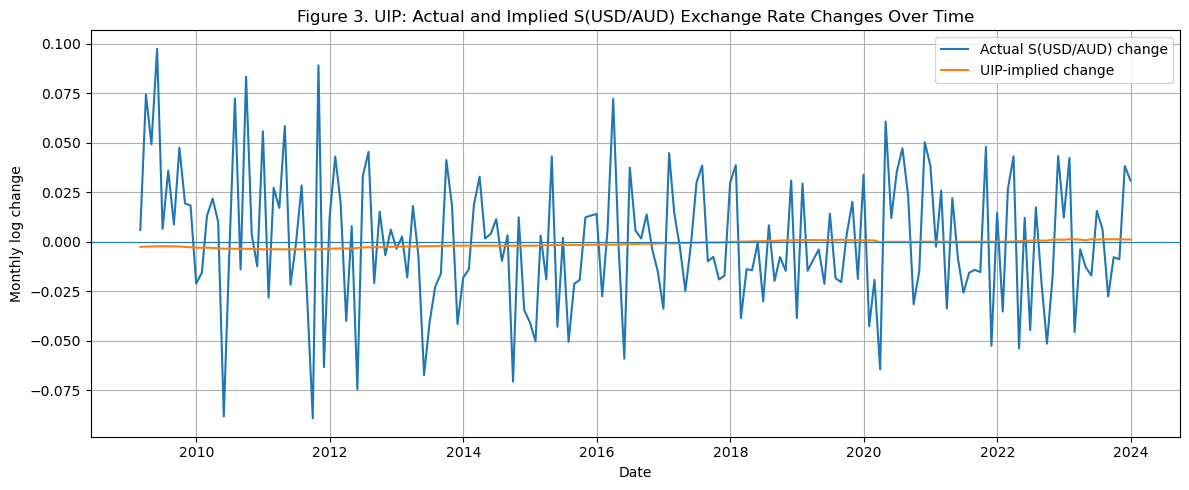

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(
    part1["Date"],
    part1["actual_fx_change"],
    label="Actual S(USD/AUD) change"
)

plt.plot(
    part1["Date"],
    part1["uip_implied_change"],
    label="UIP-implied change"
)

plt.axhline(0, linewidth=0.8)

plt.title("Figure 3. UIP: Actual and Implied S(USD/AUD) Exchange Rate Changes Over Time")
plt.xlabel("Date")
plt.ylabel("Monthly log change")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(FIG_DIR / "figure3_uip_timeseries.png", dpi=300, bbox_inches="tight")
plt.show()

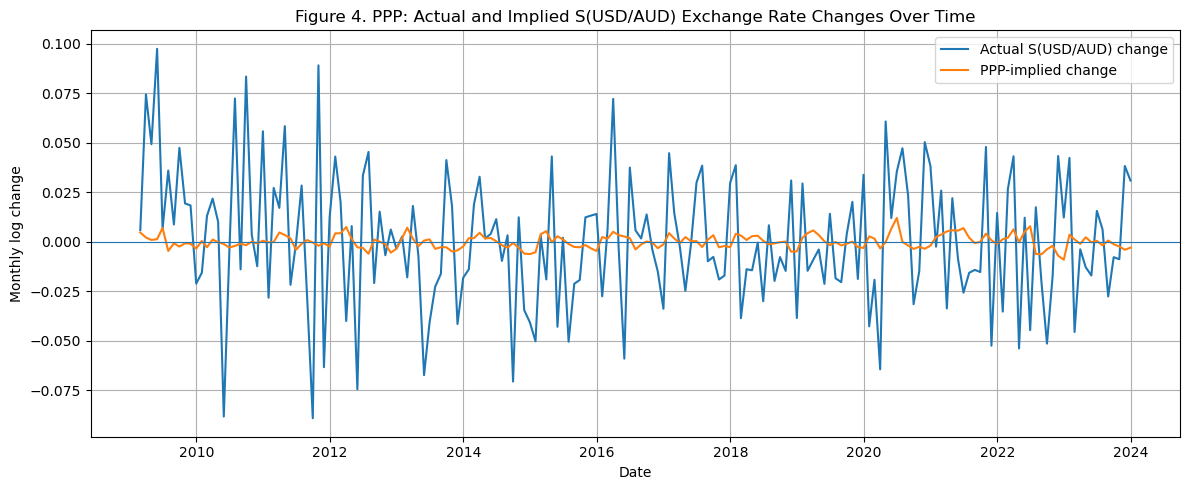

In [17]:
plt.figure(figsize=(12, 5))

plt.plot(
    part1["Date"],
    part1["actual_fx_change"],
    label="Actual S(USD/AUD) change"
)

plt.plot(
    part1["Date"],
    part1["ppp_implied_change"],
    label="PPP-implied change"
)

plt.axhline(0, linewidth=0.8)

plt.title("Figure 4. PPP: Actual and Implied S(USD/AUD) Exchange Rate Changes Over Time")
plt.xlabel("Date")
plt.ylabel("Monthly log change")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(FIG_DIR / "figure4_ppp_timeseries.png", dpi=300, bbox_inches="tight")
plt.show()

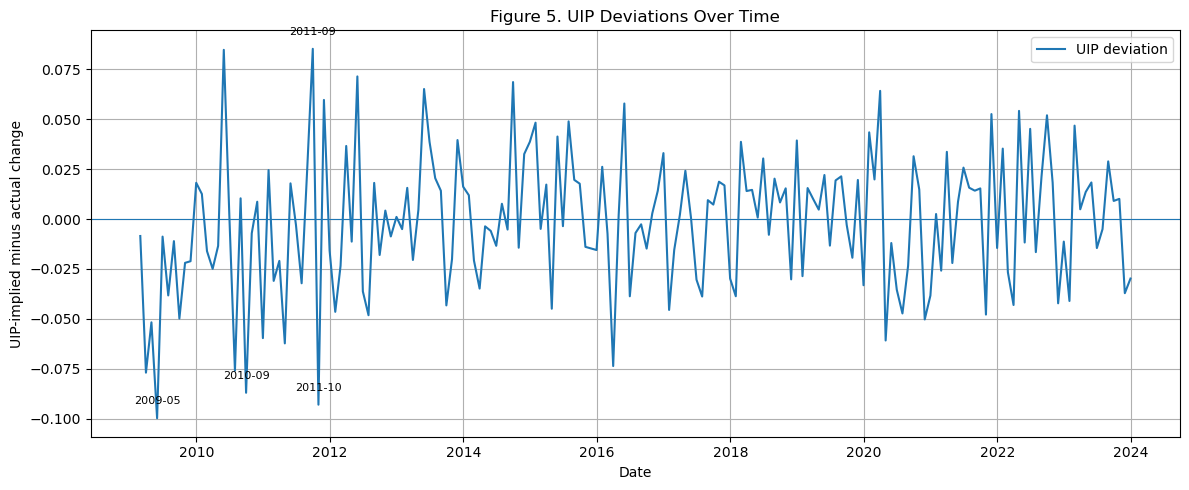

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    part1["Date"],
    part1["uip_deviation"],
    label="UIP deviation"
)

plt.axhline(0, linewidth=0.8)

# Annotate the largest absolute deviations
largest_uip = part1.loc[part1["uip_deviation"].abs().nlargest(4).index]

for _, row in largest_uip.iterrows():
    plt.annotate(
        row["Date"].strftime("%Y-%m"),
        xy=(row["Date"], row["uip_deviation"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

plt.title("Figure 5. UIP Deviations Over Time")
plt.xlabel("Date")
plt.ylabel("UIP-implied minus actual change")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(FIG_DIR / "figure5_uip_deviation.png", dpi=300, bbox_inches="tight")
plt.show()

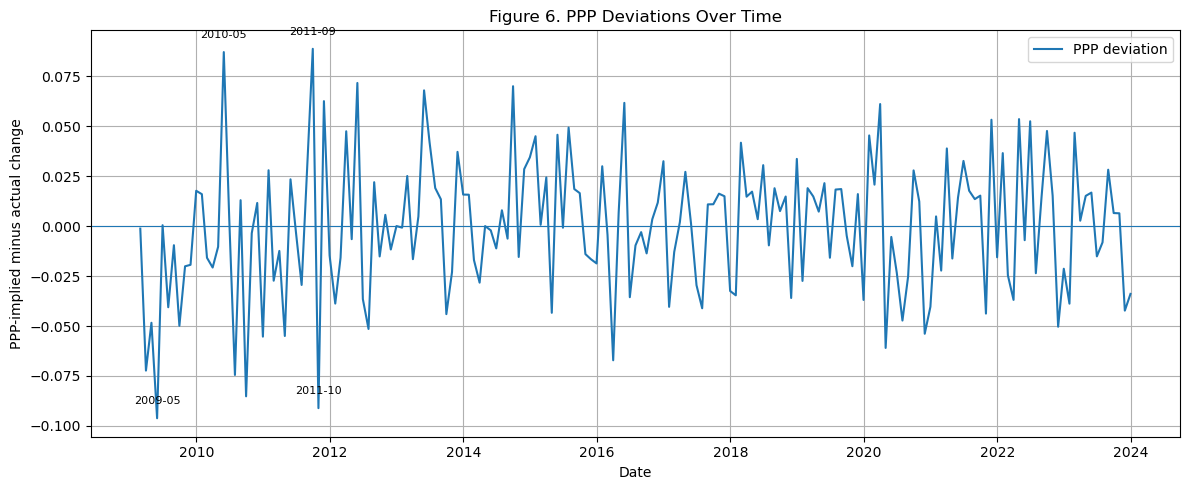

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    part1["Date"],
    part1["ppp_deviation"],
    label="PPP deviation"
)

plt.axhline(0, linewidth=0.8)

# Annotate the largest absolute deviations
largest_ppp = part1.loc[part1["ppp_deviation"].abs().nlargest(4).index]

for _, row in largest_ppp.iterrows():
    plt.annotate(
        row["Date"].strftime("%Y-%m"),
        xy=(row["Date"], row["ppp_deviation"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

plt.title("Figure 6. PPP Deviations Over Time")
plt.xlabel("Date")
plt.ylabel("PPP-implied minus actual change")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(FIG_DIR / "figure6_ppp_deviation.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
part1.to_csv(PROCESSED_DIR / "audusd_part1_corrected.csv", index=False)
summary_part1.to_csv(PROCESSED_DIR / "audusd_part1_summary_corrected.csv", index=False)

print("Saved corrected Part I dataset and summary.")
print("Part I shape:", part1.shape)

Saved corrected Part I dataset and summary.
Part I shape: (179, 12)
